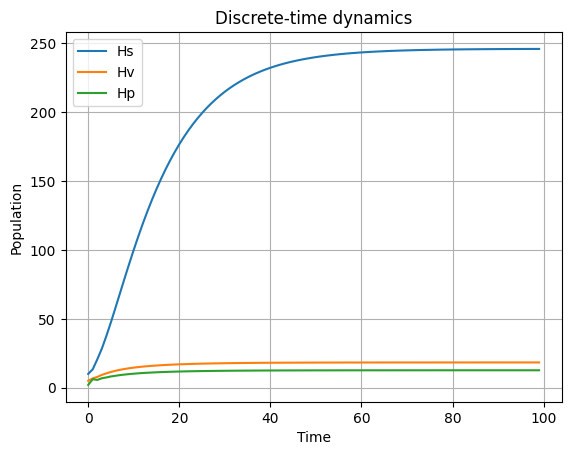

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS (set here)
# =========================
T = 100  # number of time steps

# Initial conditions
Hs = 10.0
Hv = 5.0
Hp = 2.0

# Model parameters
cs = 0.5
cv = 0.3
cp = 0.2

d = 0.1
eta = 0.05

beta_v = 0.2
beta_p = 0.3

mu = 0.1
mu_v = 0.05
mu_p = 0.05

delta_v = 0.2
delta_p = 0.3

# =========================
# STORAGE
# =========================
Hs_vals = np.zeros(T)
Hv_vals = np.zeros(T)
Hp_vals = np.zeros(T)

# =========================
# ITERATION
# =========================
for t in range(T):

    # store current values
    Hs_vals[t] = Hs
    Hv_vals[t] = Hv
    Hp_vals[t] = Hp

    # common term
    interaction = cs * Hs + cv * Hv + cp * Hp

    # compute next step
    Hs_next = (
        interaction / (1 + d + eta * interaction)
        + (1 - np.exp(-beta_v * Hv - beta_p * Hp)) * np.exp(-mu) * Hs
        + delta_v * np.exp(-mu - mu_v) * Hv
        + delta_p * np.exp(-mu - mu_p) * Hp
    )

    Hv_next = (
        np.exp(-beta_v * Hv) * np.exp(-mu) * Hs
        + (1 - delta_v) * np.exp(-mu - mu_v) * Hv
    )

    Hp_next = (
        np.exp(-beta_p * Hp) * np.exp(-mu) * Hs
        + (1 - delta_p) * np.exp(-mu - mu_p) * Hp
    )

    # update variables
    Hs = Hs_next
    Hv = Hv_next
    Hp = Hp_next

# =========================
# PLOT
# =========================
plt.plot(Hs_vals, label="Hs")
plt.plot(Hv_vals, label="Hv")
plt.plot(Hp_vals, label="Hp")

plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.title("Discrete-time dynamics")
plt.show()

In [7]:
from scipy.integrate import odeint
import scipy.optimize as opt
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import matplotlib
import seaborn as sns
from sympy import symbols, Matrix, solve, lambdify
import math
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import PySimpleGUI as sg

from scipy.integrate import odeint
import scipy.optimize as opt
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
from sympy import Symbol, symbols, Matrix, lambdify

"""

Functions used to analyze the Epi-Eco-Evo model in the manuscript 
"Towards a theory of host recovery dynamics following disease-induced declines"

"""

class Struct:
    def __init__(self, **entries):
        self.__dict__.update(entries)



In [ ]:
import numpy as np
import tkinter as tk
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# =========================
# Fixed parameters
# =========================
T = 200

cs = 0.5
cv = 0.1
cp = 0.1

d = 0.5
eta = 0.05

mu = 0.25
delta_v = 0 
delta_p = 0 #0.1

# =========================
# Initial conditions
# =========================
Hs0 = 10.0
Hv0 = 3.0
Hp0 = 3.0

# =========================
# Main window
# =========================
root = tk.Tk()
root.title("Moth Model")

# =========================
# Figure
# =========================
fig = Figure(figsize=(7, 5), dpi=100)
ax = fig.add_subplot(111)

canvas = FigureCanvasTkAgg(fig, master=root)
canvas.get_tk_widget().pack(side=tk.TOP, fill=tk.BOTH, expand=True)

# =========================
# Slider frame
# =========================
controls = tk.Frame(root)
controls.pack(side=tk.BOTTOM, fill=tk.X, padx=10, pady=10)

beta_v_var = tk.DoubleVar(value=0.2)
beta_p_var = tk.DoubleVar(value=0.3)
mu_v_var   = tk.DoubleVar(value=0.05)
mu_p_var   = tk.DoubleVar(value=0.05)

def update_plot(*args):
    beta_v = beta_v_var.get()
    beta_p = beta_p_var.get()
    mu_v = mu_v_var.get()
    mu_p = mu_p_var.get()

    Hs = [Hs0]
    Hv = [Hv0]
    Hp = [Hp0]

    for t in range(T):
        Htilde = cs * Hs[-1] + cv * Hv[-1] + cp * Hp[-1]

        Hs_new = (
            Htilde / (1 + d + eta * Htilde)
            + (1 - np.exp(-beta_v * Hv[-1] - beta_p * Hp[-1])) * np.exp(-mu) * Hs[-1]
            + delta_v * np.exp(-mu - mu_v) * Hv[-1]
            + delta_p * np.exp(-mu - mu_p) * Hp[-1]
        )

        Hv_new = (
            np.exp(-beta_v * Hv[-1]) * np.exp(-mu) * Hs[-1]
            + (1 - delta_v) * np.exp(-mu - mu_v) * Hv[-1]
        )

        Hp_new = (
            np.exp(-beta_p * Hp[-1]) * np.exp(-mu) * Hs[-1]
            + (1 - delta_p) * np.exp(-mu - mu_p) * Hp[-1]
        )

        Hs.append(Hs_new)
        Hv.append(Hv_new)
        Hp.append(Hp_new)

    time = np.arange(T + 1)

    ax.clear()
    ax.plot(time, Hs, label="Susceptible", linewidth=2.5)
    ax.plot(time, Hv, label="Inf virus", linewidth=2.5)
    ax.plot(time, Hp, label="Inf para", linewidth=2.5)
    ax.set_xlabel("time")
    ax.set_ylabel("population")
    ax.set_title("Moth Model")
    ax.grid(True)
    ax.legend()

    canvas.draw()

# =========================
# Sliders
# =========================
tk.Label(controls, text="beta_v").grid(row=0, column=0, sticky="w")
tk.Scale(
    controls, from_=0.0, to=30.0, resolution=0.01,
    orient=tk.HORIZONTAL, length=400, variable=beta_v_var,
    command=update_plot
).grid(row=0, column=1, padx=5, pady=5)

tk.Label(controls, text="beta_p").grid(row=1, column=0, sticky="w")
tk.Scale(
    controls, from_=0.0, to=30.0, resolution=0.01,
    orient=tk.HORIZONTAL, length=400, variable=beta_p_var,
    command=update_plot
).grid(row=1, column=1, padx=5, pady=5)

tk.Label(controls, text="mu_v").grid(row=2, column=0, sticky="w")
tk.Scale(
    controls, from_=0.0, to=100.0, resolution=0.01,
    orient=tk.HORIZONTAL, length=400, variable=mu_v_var,
    command=update_plot
).grid(row=2, column=1, padx=5, pady=5)

tk.Label(controls, text="mu_p").grid(row=3, column=0, sticky="w")
tk.Scale(
    controls, from_=0.0, to=100.0, resolution=0.01,
    orient=tk.HORIZONTAL, length=400, variable=mu_p_var,
    command=update_plot
).grid(row=3, column=1, padx=5, pady=5)

# Initial draw
update_plot()

root.mainloop()